In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
df = pd.read_csv("diabetic_data.csv")

import numpy as np
import pandas as pd
import scipy.stats as sp

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#task 1
numerical_stats = df.select_dtypes([float,int]).describe()
print("Descriptive Statistics for Numerical Features:")
numerical_stats

Descriptive Statistics for Numerical Features:


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,6.078800e+04,6.078800e+04,60788.000000,60788.000000,60788.000000,60788.000000,60788.000000,60788.000000,60788.000000,60788.000000,60788.000000,60788.000000,60788.000000
mean,9.671185e+07,4.146263e+07,2.175380,4.131391,6.030911,4.528558,42.749655,1.348983,15.509360,0.256778,0.139189,0.595956,7.038462
std,4.709115e+07,3.559434e+07,1.572949,5.850999,4.588237,3.062870,19.083978,1.676017,8.170832,0.947908,0.646483,1.213157,2.010280
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,5.851407e+07,9.393350e+06,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,5.000000
50%,9.831163e+07,2.492085e+07,2.000000,1.000000,7.000000,4.000000,44.000000,1.000000,14.000000,0.000000,0.000000,0.000000,8.000000
75%,1.408804e+08,7.449455e+07,3.000000,5.000000,7.000000,6.000000,56.000000,2.000000,19.000000,0.000000,0.000000,1.000000,9.000000
max,1.701039e+08,1.152185e+08,8.000000,28.000000,20.000000,14.000000,129.000000,6.000000,81.000000,36.000000,42.000000,21.000000,9.000000


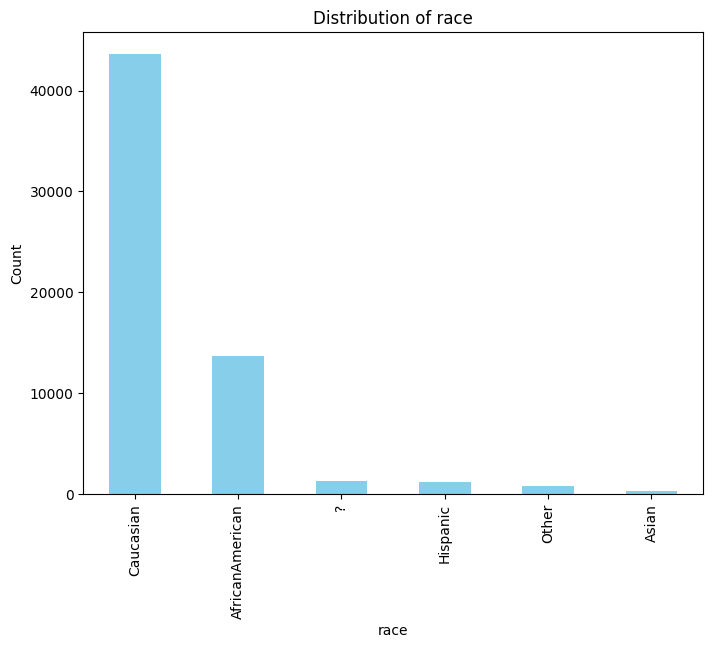

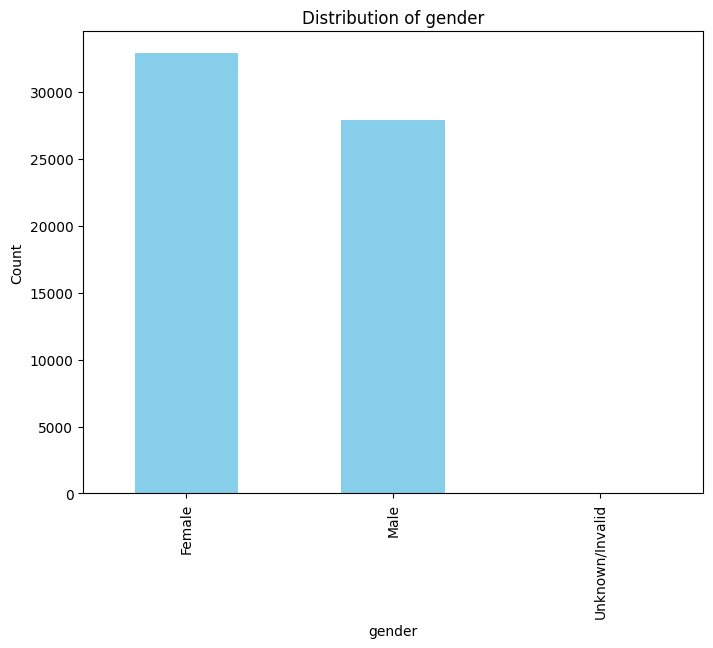

In [ ]:
#task 2
categorical_features = ['race', 'gender']
for feature in categorical_features:
    plt.figure(figsize=(8, 6))
    df[feature].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

<Figure size 1000x600 with 0 Axes>

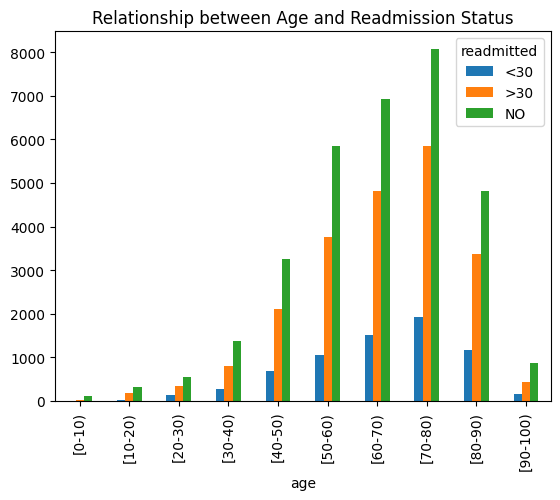

In [ ]:
#task 3
counts = pd.crosstab(df.age,df.readmitted)
plt.figure(figsize=(10, 6))
counts.plot(kind='bar')
plt.title('Relationship between Age and Readmission Status')
plt.show()

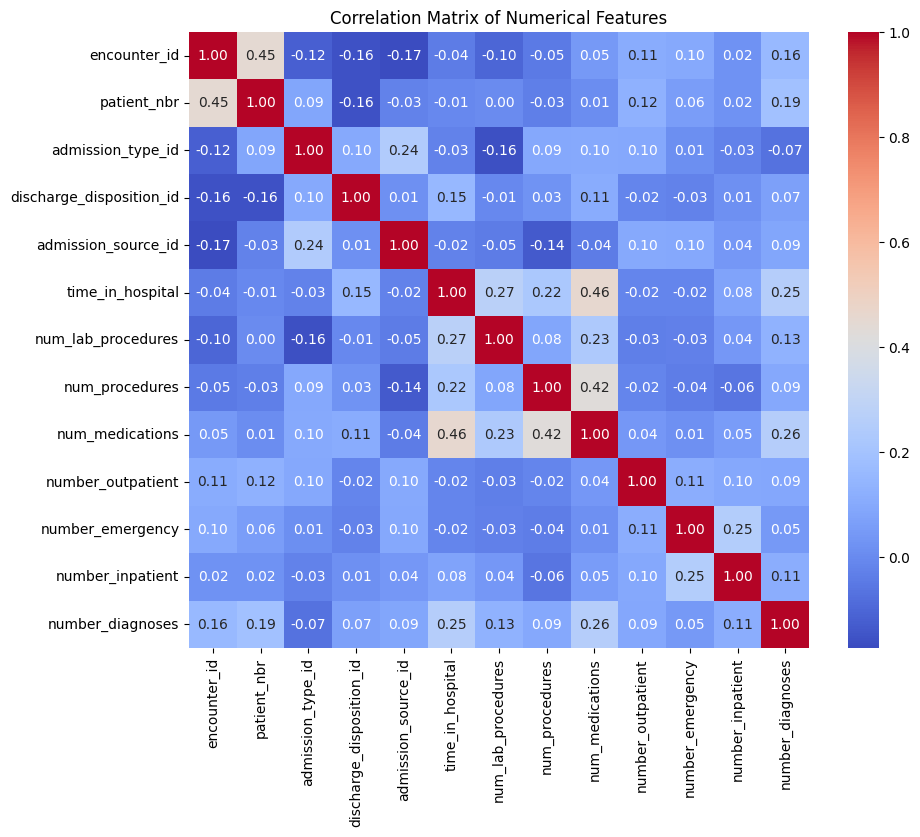

In [ ]:

#task 4
correlation_matrix = df.select_dtypes([float,int]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Correlation Matrix of Numerical Features')
plt.show()

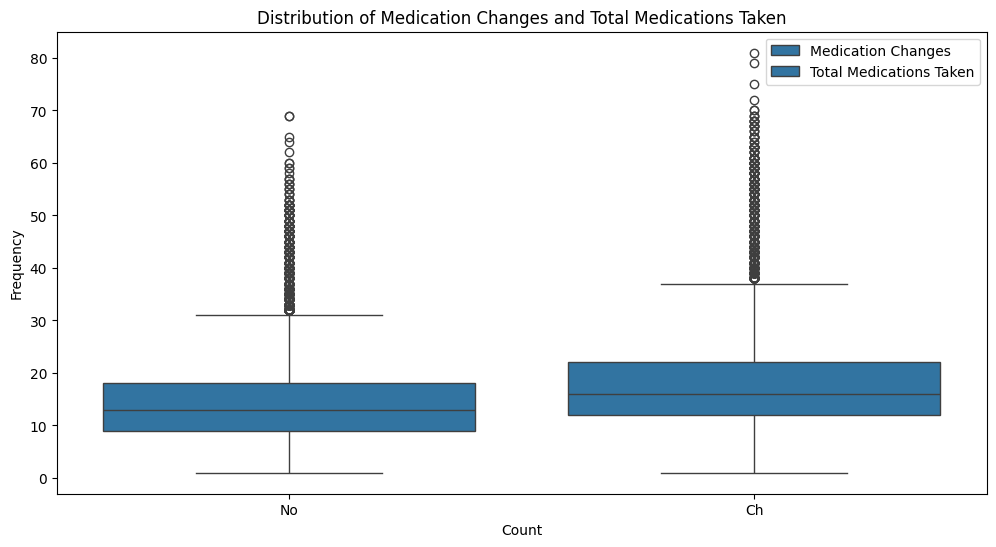

In [ ]:
#task 5
plt.figure(figsize=(12, 6))
sns.boxplot(data=df,x='change', y='num_medications')
plt.title('Distribution of Medication Changes and Total Medications Taken')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.legend(['Medication Changes', 'Total Medications Taken'])
plt.show()

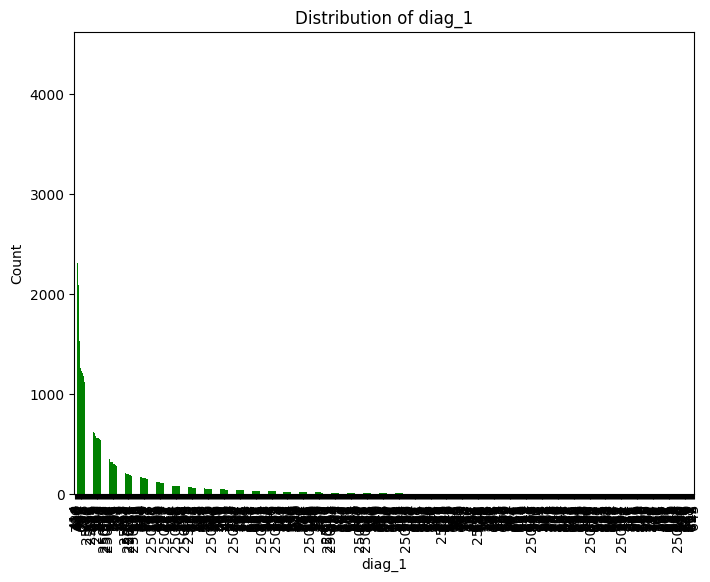

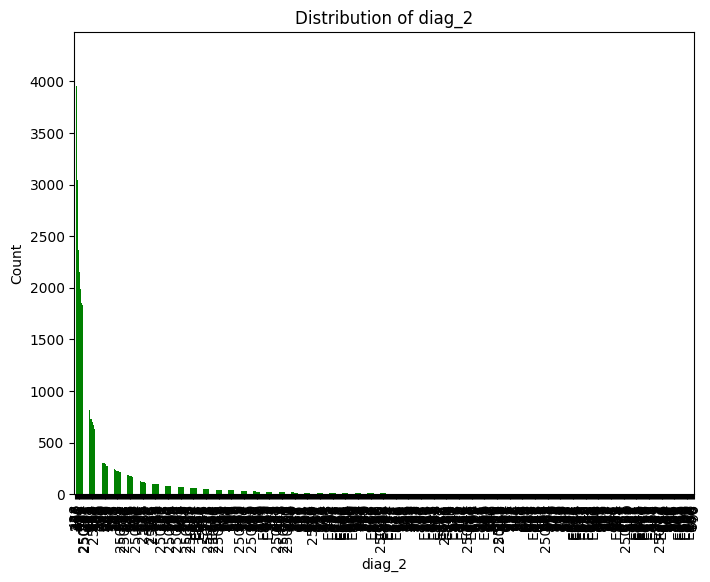

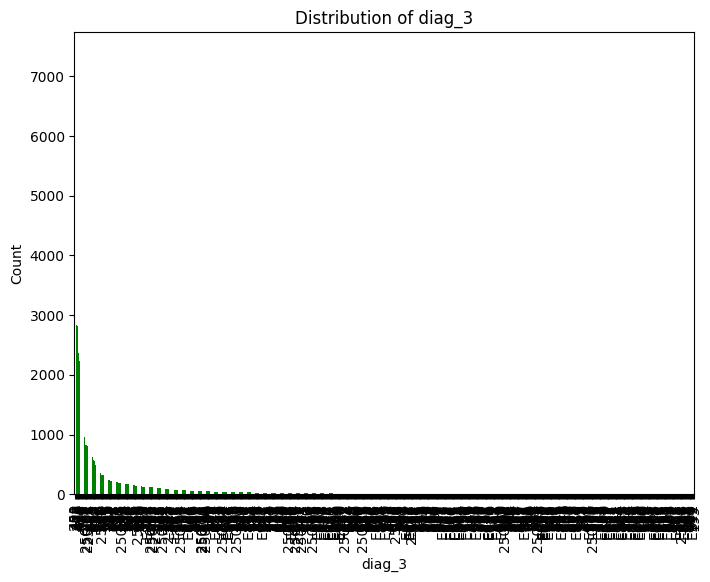

In [ ]:
#task 6
diagnosis_features = ['diag_1', 'diag_2', 'diag_3']
for feature in diagnosis_features:
    plt.figure(figsize=(8, 6))
    df[feature].value_counts().plot(kind='bar', color='green')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

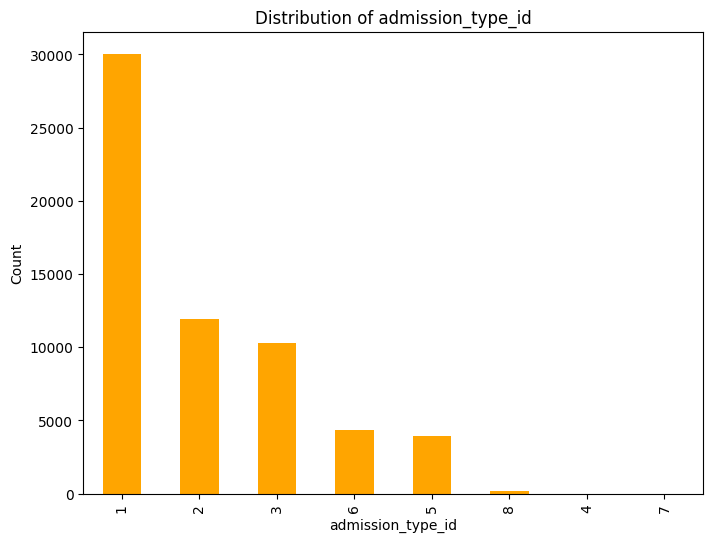

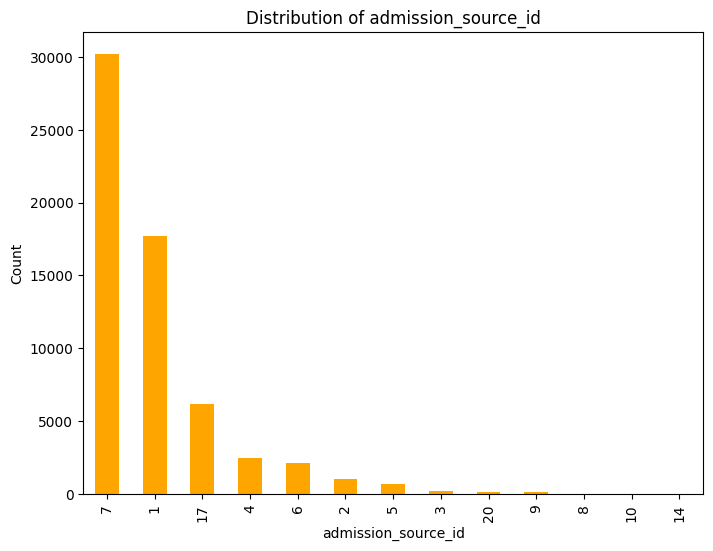

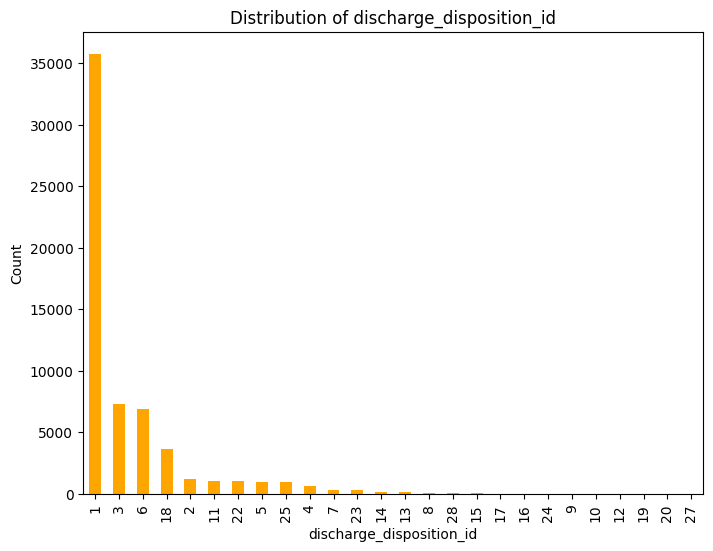

In [ ]:
#task 7

admission_features = ['admission_type_id', 'admission_source_id', 'discharge_disposition_id']
for feature in admission_features:
    plt.figure(figsize=(8, 6))
    df[feature].value_counts().plot(kind='bar', color='orange')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

Numerical columns selected:
 Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses'],
      dtype='object')

Outlier count per numerical feature:
encounter_id                    0
patient_nbr                     0
admission_type_id             288
discharge_disposition_id     9129
admission_source_id          6736
time_in_hospital             2040
num_lab_procedures            190
num_procedures               4096
num_medications              2260
number_outpatient           14061
number_emergency             9346
number_inpatient             6165
number_diagnoses              209
dtype: int64


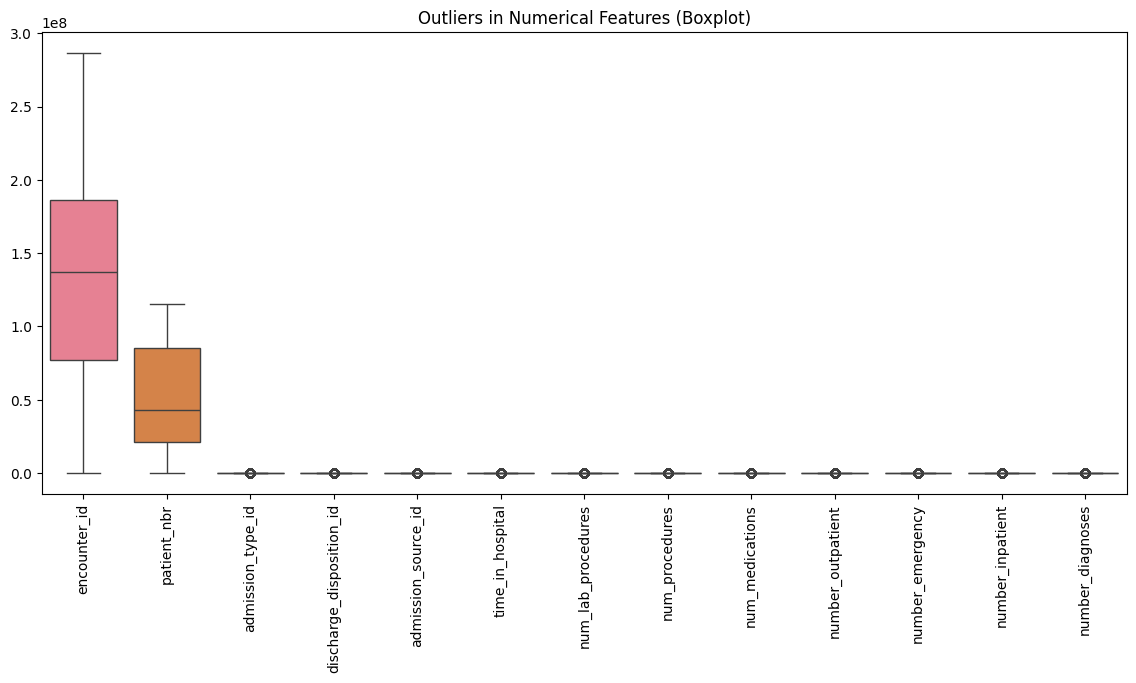

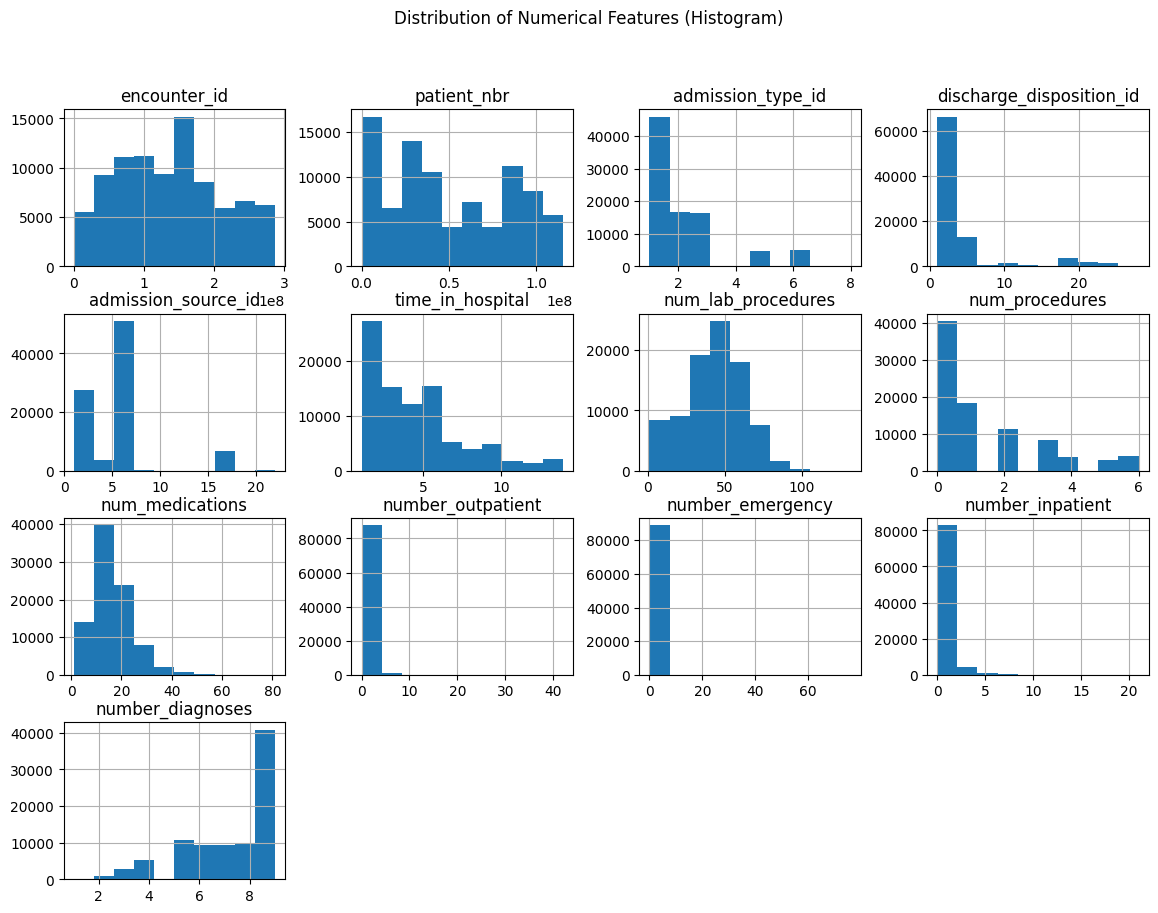

In [ ]:

numeric_df = df.select_dtypes(include=["int64", "float64"])
print("Numerical columns selected:\n", numeric_df.columns)
Q1 = numeric_df.quantile(0.25)   # 25th percentile
Q3 = numeric_df.quantile(0.75)   # 75th percentile
IQR = Q3 - Q1
outliers = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))
print("\nOutlier count per numerical feature:")
print(outliers.sum())
plt.figure(figsize=(14, 6))
sns.boxplot(data=numeric_df)
plt.title("Outliers in Numerical Features (Boxplot)")
plt.xticks(rotation=90)
plt.show()
numeric_df.hist(figsize=(14, 10))
plt.suptitle("Distribution of Numerical Features (Histogram)")
plt.show()